# 1 Imports

In [ ]:
import joblib
import pandas as pd

import funciones

# Audio de entrada

In [ ]:
audio = 'ruta/al/audio.wav'

## Extraer características

In [ ]:
caracteristicas = funciones.extract_features(audio)
df = pd.DataFrame([caracteristicas])

## Extraer gráficas

# Cargar modelos

In [ ]:
modelo_rf = joblib.load('Jorge/modelo_Random_Forest.pkl')
modelo_lgbm = joblib.load('Jorge/modelo_LightGBM.pkl')
modelo_svm = joblib.load('Jorge/modelo_SVM.pkl')

## Cargar datos de entrenamiento

In [ ]:
X_train = pd.read_csv('datos_entrenamiento.csv')

# Random Forest

## Generar predicciones

In [ ]:
y_pred_rf = modelo_rf.predict(df)
y_pred_proba_rf = modelo_rf.predict_proba(df)[:, 1]

## Generar explicaciones

### SHAP
Hay que ver bien cómo hacer esta función para que funcione ya que usa X_train y X_test (de donde los sacamos)

In [ ]:
funciones.explica_shap(modelo=modelo_rf, )

# LightGBM

## Generar predicciones

In [ ]:
y_pred_lgbm = modelo_lgbm.predict(df)
y_pred_proba_lgbm = modelo_lgbm.predict_proba(df)[:, 1]

# Support Vector Machine

## Generar predicciones

In [ ]:
y_pred_svm = modelo_svm.predict(df)
y_pred_proba_svm = modelo_svm.predict_proba(df)[:, 1]

# WAV2VEC2

Cosas que necesita el modelo

In [133]:
import torch
from datasets import load_dataset, Audio, Value
from transformers import (
    Wav2Vec2FeatureExtractor,
    Wav2Vec2ForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from scipy.special import softmax
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from pathlib import Path
import numpy as np
import librosa

In [134]:
audio = "c:\\Users\\ivire\\Documents\\GitHub\\TFG\\tfg-2526-xplicavoz\\Dataset\\Natural\\Inglés\\I_12_N.wav"

In [135]:
base = os.getcwd()

In [136]:
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    os.path.join(base,"Iván\wav2vec2-deepfake-final") # Poner ruta donde esté el modelo
)
model.eval()

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2GroupNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
          (activation): GELUActivation()
          (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        )
        (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)


In [137]:
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
    os.path.join(base,"Iván//wav2vec2-deepfake-final") # Poner ruta donde esté el modelo
)

In [138]:
SAMPLING_RATE = 16000
MAX_AUDIO_LEN = 10 * SAMPLING_RATE

def preprocess_single(audio_path, max_audio_len, sampling_rate, feature_extractor):
    # 1. Cargar audio
    audio, _ = librosa.load(audio_path, sr=sampling_rate)

    # 2. Recorte (igual que en tu dataset)
    if len(audio) > max_audio_len:
        audio = audio[:max_audio_len]

    # 3. Feature extraction
    inputs = feature_extractor(
        audio,
        sampling_rate=sampling_rate,
        padding="max_length",
        max_length=max_audio_len,
        truncation=True,
        return_tensors="pt"
    )

    return inputs["input_values"]  # tensor listo para el modelo

## Generar predicciones

In [139]:
input_values = preprocess_single(
    audio,
    MAX_AUDIO_LEN,
    SAMPLING_RATE,
    feature_extractor
)

# Inferencia
with torch.no_grad():
    outputs = model(input_values)

logits = outputs.logits

print(logits)

tensor([[ 0.4330, -0.4596]])


In [140]:
def logits_to_score(logits):
    x1, x2 = logits[0]
    return 1 / (1 + np.exp(-(x2 - x1)))

In [141]:
print("nombre =", os.path.splitext(os.path.basename(audio))[0])
print("logits =", logits)
score = float(logits_to_score(logits))
print("score =", score)


nombre = I_12_N
logits = tensor([[ 0.4330, -0.4596]])
score = 0.2905878722667694


## Generar explicaciones

Cosas que necesito para los espectrogramas

In [142]:
import torch
import numpy as np
import pandas as pd
import os

import librosa
import parselmouth
from scipy.stats import skew, kurtosis
from tqdm import tqdm
import json
import csv

from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
import math

import shap
from lime.lime_tabular import LimeTabularExplainer
from captum.attr import IntegratedGradients
from shap.plots._waterfall import waterfall_legacy

import re

import tensorflow as tf
import keras
from keras import layers

from scipy.interpolate import interp1d

from lime import lime_tabular

from tqdm import tqdm

In [143]:
def extract_spectrogram(audio_path, sr=22050, n_mels=64):
    
    y, sr = librosa.load(audio_path, sr=sr)

    spectrogram = librosa.feature.melspectrogram(
        y=y,    
        sr=sr,
        n_mels=n_mels
    )

    spectrogram_db = librosa.power_to_db(spectrogram, ref=np.max)

    return spectrogram_db

def espectrogramas(df):

    specs = []

    for path in tqdm(df["path"]):
            spec = extract_spectrogram(path)
            specs.append(spec)

    df["espectrograma_mel"] = specs

    return df

Surrogate model

In [144]:
def build_surrogate(): 
    inputs = tf.keras.Input(shape=(64,128,1)) 
    x = layers.Conv2D(4, (3,3), activation="relu", name="conv")(inputs)
    x = layers.GlobalAveragePooling2D()(x)
        
    outputs = layers.Dense(1, activation="sigmoid")(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile( 
        optimizer="adam", 
        loss="mse" )
    
    return model

In [145]:
def agrupar_bandas(spec, n_grupos=8, fixed_time=128):
    mel_bins, time = spec.shape
    tam_grupo = mel_bins // n_grupos

    bandas = []

    for i in range(n_grupos):
        inicio = i * tam_grupo
        fin = (i + 1) * tam_grupo

        banda = spec[inicio:fin, :]

        banda = librosa.util.fix_length(banda.mean(axis=0), size=fixed_time)

        bandas.append(banda)

    return np.array(bandas)

Entrenamiento del modelo

In [146]:
df_train = pd.read_csv("datos_entrenamiento_espectrogramas.csv")

espectrogramas(df_train)

aux = pd.read_csv("c:\\Users\\ivire\\Documents\\GitHub\\TFG\\tfg-2526-xplicavoz\\Dataset\\todosLosAudiosMezcladosyDivididos\\out.csv")

df_train["salida_wav2vec2"] = aux["score"]

100%|██████████| 200/200 [00:06<00:00, 29.08it/s]


In [147]:
model_espectrogramas = build_surrogate()

X = df_train["espectrograma_mel"]

TARGET_TIME = 128

def fix_spec(spec):

    spec = spec[:64, :TARGET_TIME]

    if spec.shape[1] < TARGET_TIME:
        pad = TARGET_TIME - spec.shape[1]
        spec = np.pad(spec, ((0,0),(0,pad)))

    return spec

X = np.stack(df_train["espectrograma_mel"].apply(fix_spec).values)
X = (X - X.mean()) / (X.std() + 1e-8)
X = X[..., np.newaxis]

In [148]:
X_tensor = tf.convert_to_tensor(X, dtype=tf.float32)

y = df_train["salida_wav2vec2"]
y_tensor = tf.convert_to_tensor(y, dtype=tf.float32)

model_espectrogramas.fit(X_tensor,y_tensor,epochs=50,batch_size=4,verbose=0)

### Mel spectrogram

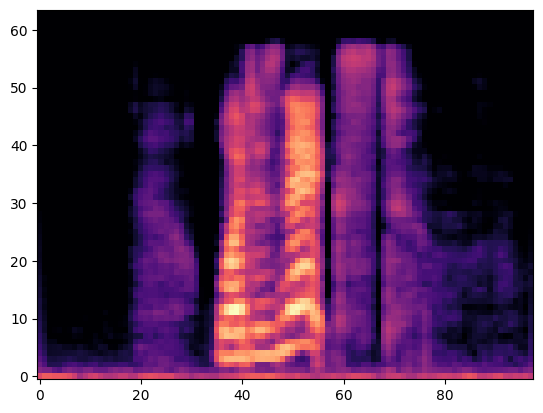

In [149]:
mel_spec = extract_spectrogram(audio)  # (64, tiempo)

plt.imshow(mel_spec, aspect='auto', origin='lower', cmap='magma')

### SHAP


In [150]:
X_np = X_tensor.numpy()

background = X_np[:50]

explainer_SHAP_espectrogramas = shap.GradientExplainer(model_espectrogramas, background)
shap_values_espectrogramas = explainer_SHAP_espectrogramas.shap_values(X_np)

`tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.


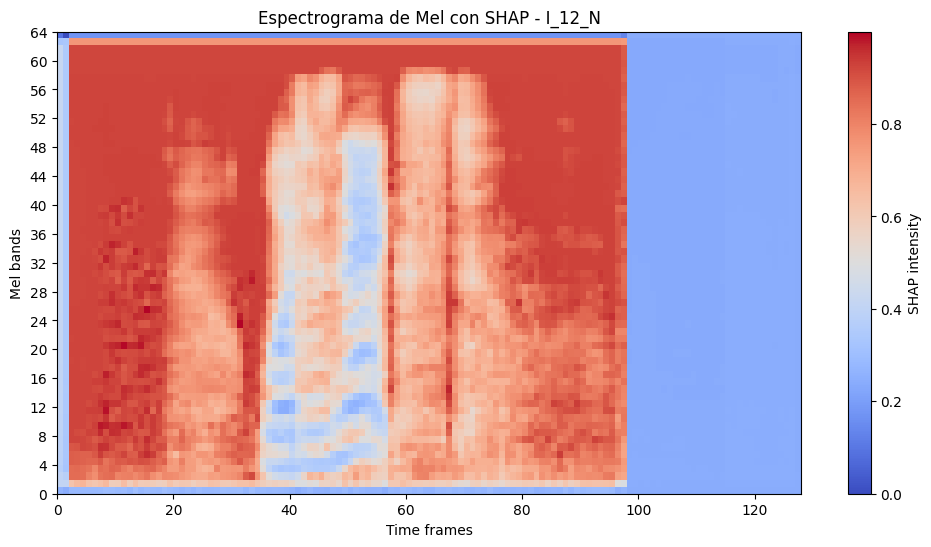

In [151]:
mel_spec = extract_spectrogram(audio)
mel_spec = fix_spec(mel_spec)  # (64, tiempo)

input_model = mel_spec[np.newaxis, ..., np.newaxis]  # (1, 8, tiempo, 1)

shap_vals = explainer_SHAP_espectrogramas.shap_values(input_model)[0][0, ..., 0]  # (8, tiempo)

n_mels, n_frames = mel_spec.shape
n_superbands = shap_vals.shape[0]

shap_heatmap = np.zeros_like(mel_spec)
band_height = n_mels // n_superbands

for i in range(n_superbands):
    f = interp1d(
        np.arange(shap_vals.shape[1]),
        shap_vals[i],
        kind='linear',
        fill_value="extrapolate"
    )
    
    band_values = f(np.arange(n_frames))
    
    start = i * band_height
    end = (i + 1) * band_height if i < n_superbands - 1 else n_mels
    
    shap_heatmap[start:end, :] = np.tile(band_values, (end - start, 1))

shap_heatmap_norm = (
    (shap_heatmap - shap_heatmap.min()) /
    (shap_heatmap.max() - shap_heatmap.min() + 1e-8)
)

# Gráfica
plt.figure(figsize=(12,6))
plt.imshow(
    mel_spec,
    aspect='auto',
    origin='lower',
    cmap='magma',
    extent=[0, mel_spec.shape[1], 0, 64]
)

plt.imshow(
    shap_heatmap_norm,
    aspect='auto',
    origin='lower',
    cmap='coolwarm',
    alpha=1,
    extent=[0, mel_spec.shape[1], 0, 64]
)

plt.yticks(list(range(0, 65, 4)))

plt.colorbar(label='SHAP intensity')
plt.xlabel('Time frames')
plt.ylabel('Mel bands')
plt.title(f'Espectrograma de Mel con SHAP - {os.path.splitext(os.path.basename(audio))[0]}')
plt.show()

### INTEGRATED GRADIENTS


In [152]:
def integrated_gradients(model, x, baseline=None, steps=50):

    x = tf.cast(x, tf.float32)

    if baseline is None:
        baseline = tf.zeros_like(x)

    # generar interpolaciones
    alphas = tf.linspace(0.0, 1.0, steps+1)

    gradients = []

    for alpha in alphas:
        x_step = baseline + alpha * (x - baseline)

        with tf.GradientTape() as tape:
            tape.watch(x_step)
            pred = model(tf.expand_dims(x_step, axis=0), training=False)

        grad = tape.gradient(pred, x_step)
        gradients.append(grad)

    gradients = tf.stack(gradients)

    # promedio de gradientes
    avg_gradients = tf.reduce_mean(gradients[:-1], axis=0)

    # integrated gradients
    integrated_grads = (x - baseline) * avg_gradients

    return integrated_grads.numpy()

In [153]:
x_audio = mel_spec

ig = integrated_gradients(model_espectrogramas, x_audio, steps=100)

# quitar canal
#ig = ig[:,:,0]

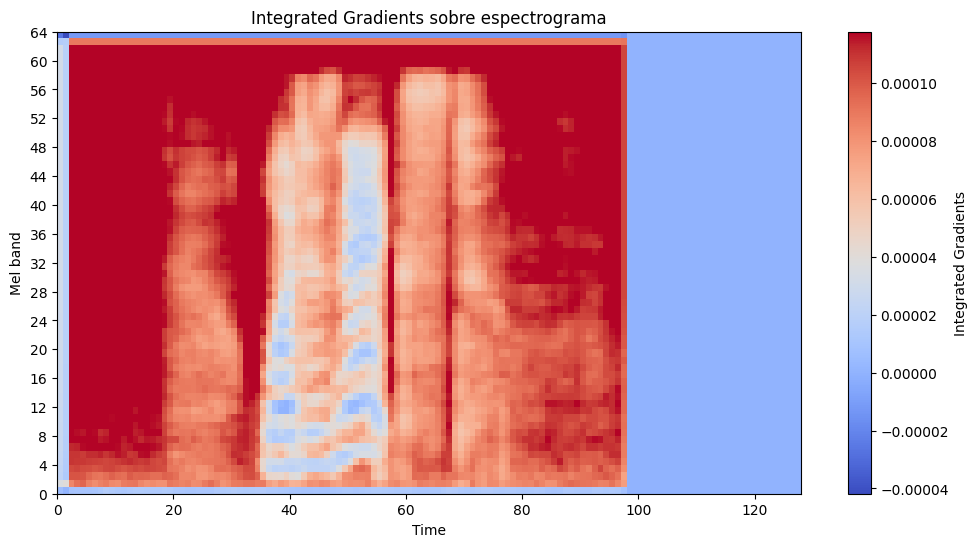

In [154]:
#spectrogram = x_audio[:,:,0]

plt.figure(figsize=(12,6))

plt.imshow(x_audio, aspect="auto", origin="lower", cmap="magma", extent=[0, mel_spec.shape[1], 0, 64])
plt.imshow(ig, aspect="auto", origin="lower", cmap="coolwarm", alpha=1, extent=[0, mel_spec.shape[1], 0, 64])
plt.yticks(list(range(0, 65, 4)))


plt.colorbar(label="Integrated Gradients")
plt.title("Integrated Gradients sobre espectrograma")
plt.xlabel("Time")
plt.ylabel("Mel band")

plt.show()

In [1]:
import torch
from funciones_aux import *

model = torch.jit.load("German/aasist_scripted.pt", map_location="cpu")
model.eval()
audio = r"C:\TFG\Datasets\Propio\Generado\Español\E_1_G.wav"
res = score_audio(audio, model) 
print(res)
aplicar_XAI(wav_path = audio, model = model) 

{'logits': tensor([[ 3.9811, -4.0616]]), 'score_bonafide': -4.06155252456665, 'prob_bonafide': 0.0003213507297914475, 'pred_clase': 0}


In [1]:
import sys
from pathlib import Path
import torch
from funciones_aux import *

device = "cpu"

sys.path.insert(0, str((Path.cwd() / "German").resolve()))

from AASIST import Model

model = torch.load("German/aasist_full.pt", map_location=device, weights_only=False)
model.eval()

print(model.d_args)
print(model.conv_time)
audio = r"C:\TFG\Datasets\Propio\Generado\Español\E_1_G.wav"
res = score_audio(audio, model) 
print(res)
aplicar_XAI(wav_path = audio, model = model) 

{'architecture': 'AASIST', 'nb_samp': 64600, 'first_conv': 128, 'filts': [70, [1, 32], [32, 32], [32, 64], [64, 64]], 'gat_dims': [64, 32], 'pool_ratios': [0.5, 0.7, 0.5, 0.5], 'temperatures': [2.0, 2.0, 100.0, 100.0]}
CONV()
{'logits': tensor([[ 3.9811, -4.0616]]), 'score_bonafide': -4.06155252456665, 'prob_bonafide': 0.0003213507297914475, 'pred_clase': 0}
